In [4]:
# Peak 감지하는 변수를 3개로 나눔
# 1) min_distance_sec = 각 피크간 최소 시간 갭
# 2) sensitivity = 민감도 (0~1 / 0은 감지 안함 1은 다 감지함)
# 3) min_peak_ratio = 가장 큰 피크 대비 몇 % 크기의 피크만 감지

# both, neg, pos 피크 감지 모드 삭제 (통합함)

In [5]:
# CSV folder
folder_path = r"C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1. [Lead] Polariztion DEG w Jiwon\1. 실험자료\261006_DC-DEG로도 시나리오 체크\0minimized_csv파일"

# User choices
detection_mode = "voltage"   # "voltage" or "current"

current_scale = 10        # only for current mode, example: 10 = 10 uA/V

# Peak tuning: only 3 variables
min_distance_sec = 0.05   # minimum gap between nearby peaks
sensitivity = 0.95        # 0.0 almost no detection, 1.0 very sensitive
min_peak_ratio = 0.1    # 0.20 means 20 percent of the strongest peak in each file

EXCERPT_PEAK_COUNT = 4   # cycles (pairs) for peak-to-peak excerpt selection

# Optional time-range extraction / analysis
time_range = None        # None or (start_sec, end_sec)
save_time_filtered_csv = False

# Plot / file options
y_range = (None, None)
#y_range = (-10, 10)
save_summary_csv = False #True 


Mode: voltage
Folder: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1. [Lead] Polariztion DEG w Jiwon\1. 실험자료\261006_DC-DEG로도 시나리오 체크\0minimized_csv파일
Time range: None
------------------------------------------------------------------------
Ch1-needle_Ch4-elec
Mode: peak-to-peak | distance >= 0.050s | sensitivity 0.950 | min peak >= 10%

Ch1 | Vpp 10.118 V | Peaks 33 | Std 2.829 V | Freq 1.740 Hz
  Excerpt 4 cycles (8 peaks) | Sum 50.211 V | Mean Vpp 12.339 V | Std 1.305 V | Freq 1.679 Hz
Ch2 | Vpp 11.039 V | Peaks 33 | Std 3.111 V | Freq 1.740 Hz
  Excerpt 4 cycles (8 peaks) | Sum 54.825 V | Mean Vpp 13.776 V | Std 2.119 V | Freq 1.679 Hz
------------------------------------------------------------------------


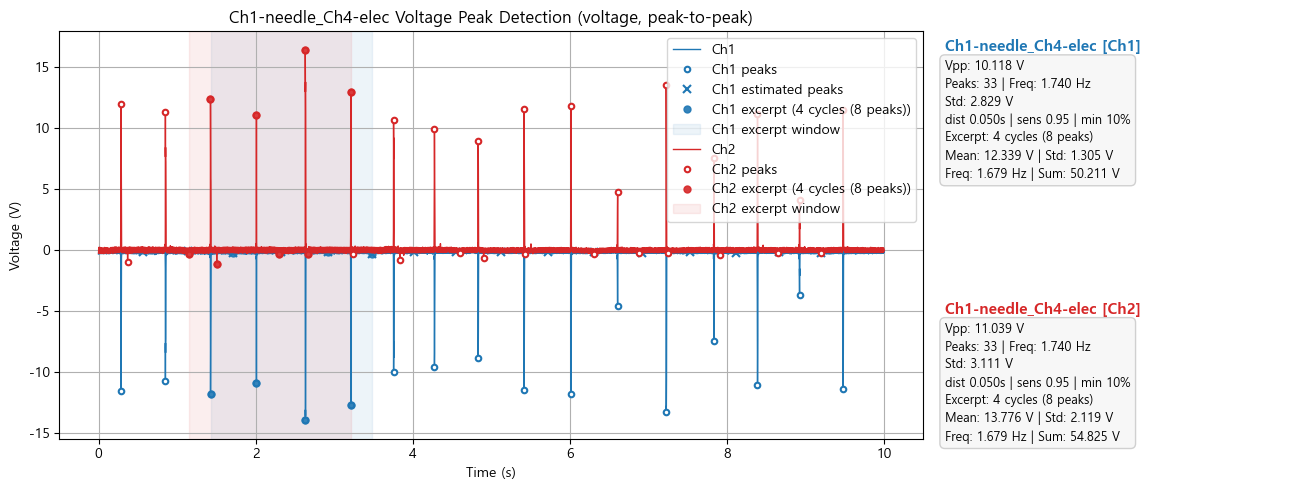

------------------------------------------------------------------------
Scenario-metal
Mode: peak-to-peak | distance >= 0.050s | sensitivity 0.950 | min peak >= 10%

Ch1 | Vpp 9.587 V | Peaks 101 | Std 6.607 V | Freq 1.260 Hz
  Excerpt 4 cycles (8 peaks) | Sum 87.036 V | Mean Vpp 20.511 V | Std 5.651 V | Freq 1.574 Hz
------------------------------------------------------------------------


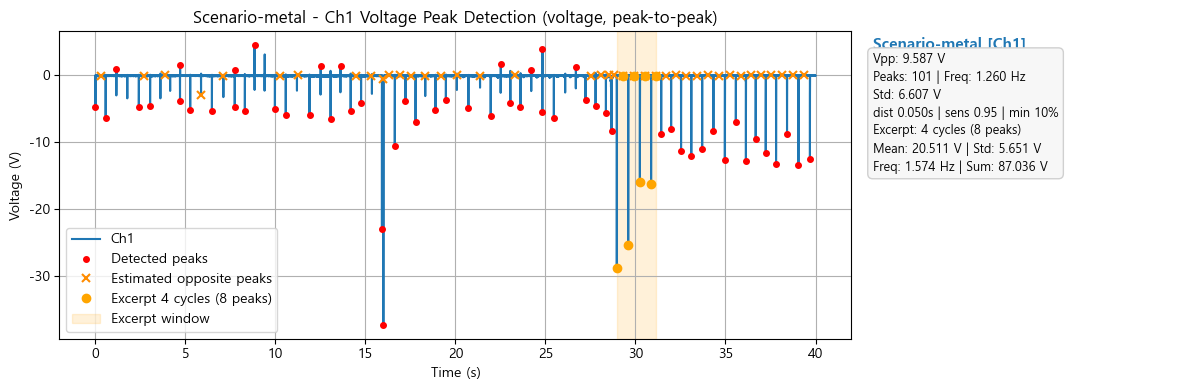


Excerpt summary (4 cycles (8 peaks))
File                    | Channel | Vpp (V) | Std (V) | Freq (Hz) | Peaks
-------------------------------------------------------------------------
Ch1-needle_Ch4-elec.csv | Ch1     |  12.339 |   1.305 |     1.679 |     8
Ch1-needle_Ch4-elec.csv | Ch2     |  13.776 |   2.119 |     1.679 |     8
Scenario-metal.csv      | Ch1     |  20.511 |   5.651 |     1.574 |     8

Average excerpt Vpp: 15.542 V
Average excerpt Std: 3.025 V
Average excerpt Frequency: 1.644 Hz

Full summary (voltage, mode=peak-to-peak)
File                    | Channel | Vpp (V) | Std (V) | Freq (Hz) | Peaks
-------------------------------------------------------------------------
Ch1-needle_Ch4-elec.csv | Ch1     |  10.118 |   2.829 |     1.740 |    33
Ch1-needle_Ch4-elec.csv | Ch2     |  11.039 |   3.111 |     1.740 |    33
Scenario-metal.csv      | Ch1     |   9.587 |   6.607 |     1.260 |   101

Average Vpp: 10.248 V
Average Std: 4.182 V
Average Frequency: 1.580 Hz


In [6]:
import os
from itertools import cycle

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from scipy.signal import find_peaks


def configure_korean_font():
    """Use an installed font that can display Korean file names in plots."""
    preferred_fonts = [
        "Malgun Gothic",      # Windows
        "AppleGothic",        # macOS
        "Noto Sans KR",       # Linux / cross-platform
        "NanumGothic",
        "Hancom Gothic",
    ]
    installed_fonts = {font.name for font in font_manager.fontManager.ttflist}

    for font_name in preferred_fonts:
        if font_name in installed_fonts:
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_name

    print("Warning: No Korean font was found. Install Malgun Gothic, Noto Sans KR, or NanumGothic.")
    return None


KOREAN_FONT = configure_korean_font()


PLOT_COLORS = [
    "#1f77b4",
    "#d62728",
    "#2ca02c",
    "#ff7f0e",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
]


def _normalize_index_array(values):
    if values is None:
        return np.array([], dtype=int)
    return np.asarray(values, dtype=int)


def build_peak_summary_text(
    *,
    analysis_label,
    analysis_unit,
    peak_count,
    mean_analysis,
    std_analysis,
    mean_freq,
    threshold_distance=None,
    sensitivity=None,
    min_peak_ratio=None,
    excerpt_label=None,
    excerpt_peak_sum=None,
    excerpt_mean_analysis=None,
    excerpt_std_analysis=None,
    excerpt_mean_freq=None,
):
    lines = [
        f"{analysis_label}: {mean_analysis:.3f} {analysis_unit}",
        f"Peaks: {int(peak_count)} | Freq: {mean_freq:.3f} Hz",
        f"Std: {std_analysis:.3f} {analysis_unit}",
    ]

    if (
        threshold_distance is not None
        and sensitivity is not None
        and min_peak_ratio is not None
    ):
        lines.append(
            f"dist {threshold_distance:.3f}s | sens {sensitivity:.2f} | min {min_peak_ratio * 100:.0f}%"
        )

    if excerpt_label is not None and excerpt_mean_analysis is not None:
        lines.extend(
            [
                f"Excerpt: {excerpt_label}",
                f"Mean: {excerpt_mean_analysis:.3f} {analysis_unit} | Std: {excerpt_std_analysis:.3f} {analysis_unit}",
                f"Freq: {excerpt_mean_freq:.3f} Hz | Sum: {excerpt_peak_sum:.3f} {analysis_unit}",
            ]
        )

    return "\n".join(lines)


def build_peak_report_block(
    *,
    file_label,
    analysis_label,
    analysis_unit,
    peak_mode_label,
    threshold_distance,
    sensitivity,
    min_peak_ratio,
    channel_reports,
):
    lines = [
        "-" * 72,
        file_label,
        (
            f"Mode: {peak_mode_label} | distance >= {threshold_distance:.3f}s"
            f" | sensitivity {sensitivity:.3f} | min peak >= {min_peak_ratio * 100:.0f}%"
        ),
        "",
    ]

    channel_width = max(len(report["channel_name"]) for report in channel_reports)
    mean_width = max(len(f"{report['mean_analysis']:.3f} {analysis_unit}") for report in channel_reports)
    peak_width = max(len(str(int(report["peak_count"]))) for report in channel_reports)
    std_width = max(len(f"{report['std_analysis']:.3f} {analysis_unit}") for report in channel_reports)
    freq_width = max(len(f"{report['mean_freq']:.3f} Hz") for report in channel_reports)

    excerpt_reports = [report for report in channel_reports if report.get("excerpt_mean_analysis") is not None]
    if excerpt_reports:
        excerpt_label_width = max(len(str(report["excerpt_label"])) for report in excerpt_reports)
        excerpt_sum_width = max(len(f"{report['excerpt_peak_sum']:.3f} {analysis_unit}") for report in excerpt_reports)
        excerpt_mean_width = max(len(f"{report['excerpt_mean_analysis']:.3f} {analysis_unit}") for report in excerpt_reports)
        excerpt_std_width = max(len(f"{report['excerpt_std_analysis']:.3f} {analysis_unit}") for report in excerpt_reports)
        excerpt_freq_width = max(len(f"{report['excerpt_mean_freq']:.3f} Hz") for report in excerpt_reports)

    for report in channel_reports:
        mean_text = f"{report['mean_analysis']:.3f} {analysis_unit}"
        peak_text = str(int(report["peak_count"]))
        std_text = f"{report['std_analysis']:.3f} {analysis_unit}"
        freq_text = f"{report['mean_freq']:.3f} Hz"

        lines.append(
            (
                f"{report['channel_name']:<{channel_width}}"
                f" | {analysis_label} {mean_text:>{mean_width}}"
                f" | Peaks {peak_text:>{peak_width}}"
                f" | Std {std_text:>{std_width}}"
                f" | Freq {freq_text:>{freq_width}}"
            )
        )

        if report.get("excerpt_mean_analysis") is not None:
            excerpt_sum_text = f"{report['excerpt_peak_sum']:.3f} {analysis_unit}"
            excerpt_mean_text = f"{report['excerpt_mean_analysis']:.3f} {analysis_unit}"
            excerpt_std_text = f"{report['excerpt_std_analysis']:.3f} {analysis_unit}"
            excerpt_freq_text = f"{report['excerpt_mean_freq']:.3f} Hz"

            lines.append(
                (
                    f"  Excerpt {str(report['excerpt_label']):<{excerpt_label_width}}"
                    f" | Sum {excerpt_sum_text:>{excerpt_sum_width}}"
                    f" | Mean {analysis_label} {excerpt_mean_text:>{excerpt_mean_width}}"
                    f" | Std {excerpt_std_text:>{excerpt_std_width}}"
                    f" | Freq {excerpt_freq_text:>{excerpt_freq_width}}"
                )
            )

    lines.append("-" * 72)
    return "\n".join(lines)


def _create_plot_axes(figsize, has_summary):
    if has_summary:
        fig, (ax, summary_ax) = plt.subplots(
            1,
            2,
            figsize=figsize,
            gridspec_kw={"width_ratios": [4.8, 1.9]},
        )
        summary_ax.axis("off")
        return fig, ax, summary_ax

    fig, ax = plt.subplots(figsize=figsize)
    return fig, ax, None


def _draw_summary_panel(summary_ax, summary_blocks):
    if summary_ax is None or not summary_blocks:
        return

    y_pos = 0.98

    for block in summary_blocks:
        title = block["title"]
        body = block["body"]
        color = block.get("color", "#333333")

        summary_ax.text(
            0.02,
            y_pos,
            title,
            color=color,
            fontsize=11,
            fontweight="bold",
            ha="left",
            va="top",
        )

        summary_ax.text(
            0.02,
            y_pos - 0.05,
            body,
            fontsize=9,
            ha="left",
            va="top",
            linespacing=1.45,
            bbox={
                "boxstyle": "round,pad=0.4",
                "facecolor": "#f7f7f7",
                "edgecolor": "#d0d0d0",
            },
        )

        line_count = body.count("\n") + 1
        y_pos -= 0.12 + line_count * 0.075


def load_multichannel_csv(file_path, *, header=None, skiprows=0, current_scale=None):
    df = pd.read_csv(file_path, header=header, skiprows=skiprows)
    df = df.apply(pd.to_numeric, errors="coerce").dropna(how="all")

    if df.shape[1] < 2:
        raise ValueError("At least 2 columns are required: Time + 1 channel.")

    df.columns = ["Time"] + [f"Ch{i}" for i in range(1, df.shape[1])]
    df = df.dropna(subset=["Time"]).reset_index(drop=True)

    if current_scale is not None:
        signal_cols = list(df.columns[1:])
        df.loc[:, signal_cols] = df.loc[:, signal_cols] * float(current_scale)

    return df


def filter_time_range(df, time_range, *, shift_to_zero=False):
    if time_range is None:
        return df.copy()

    if len(time_range) != 2:
        raise ValueError("time_range must be None or a tuple like (start, end).")

    start, end = map(float, time_range)
    filtered = df[(df["Time"] >= start) & (df["Time"] <= end)].copy()

    if filtered.empty:
        raise ValueError(f"No data found in time range {time_range}.")

    filtered.reset_index(drop=True, inplace=True)

    if shift_to_zero:
        filtered.loc[:, "Time"] = filtered["Time"] - float(filtered.loc[0, "Time"])

    return filtered


def save_cut_csv(df, file_path):
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    df.to_csv(file_path, index=False, header=False, encoding="utf-8-sig")


def plot_multichannel_overview(
    df,
    *,
    title,
    ylabel,
    figsize=(10, 5),
    y_range=None,
    legend=True,
):
    plt.figure(figsize=figsize)
    color_iter = cycle(PLOT_COLORS)

    for channel in df.columns[1:]:
        plt.plot(df["Time"], df[channel], label=channel, color=next(color_iter), linewidth=1.0)

    plt.xlabel("Time (s)")
    plt.ylabel(ylabel)
    plt.title(title)

    if y_range is not None:
        plt.ylim(y_range)

    plt.grid(True)

    if legend:
        plt.legend()

    plt.tight_layout()
    plt.show()


def plot_peak_detection_result(
    *,
    time_values,
    signal_values,
    channel_name,
    title,
    ylabel,
    line_color,
    main_peaks=None,
    synthetic_peaks=None,
    excerpt_idx=None,
    excerpt_label=None,
    summary_title=None,
    summary_text=None,
    y_range=None,
    figsize=(10, 4),
):
    main_peaks = _normalize_index_array(main_peaks)
    synthetic_peaks = _normalize_index_array(synthetic_peaks)
    excerpt_idx = _normalize_index_array(excerpt_idx)
    real_main_peaks = np.setdiff1d(main_peaks, synthetic_peaks, assume_unique=False)

    fig, ax, summary_ax = _create_plot_axes(figsize, has_summary=bool(summary_text))
    ax.plot(time_values, signal_values, color=line_color, label=channel_name)

    if len(real_main_peaks) > 0:
        ax.plot(
            time_values[real_main_peaks],
            signal_values[real_main_peaks],
            "o",
            ms=4,
            color="red",
            label="Detected peaks",
        )

    if len(synthetic_peaks) > 0:
        ax.plot(
            time_values[synthetic_peaks],
            signal_values[synthetic_peaks],
            "x",
            ms=6,
            mew=1.5,
            color="darkorange",
            label="Estimated opposite peaks",
        )

    if len(excerpt_idx) > 0:
        excerpt_text = f"Excerpt {excerpt_label}" if excerpt_label else "Excerpt"
        ax.plot(
            time_values[excerpt_idx],
            signal_values[excerpt_idx],
            "o",
            ms=6,
            color="orange",
            label=excerpt_text,
        )
        ax.axvspan(
            time_values[excerpt_idx[0]],
            time_values[excerpt_idx[-1]],
            alpha=0.15,
            color="orange",
            label="Excerpt window",
        )

    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(ylabel)

    if y_range is not None:
        ax.set_ylim(y_range)

    ax.grid(True)
    ax.legend(loc="best")

    if summary_text:
        _draw_summary_panel(
            summary_ax,
            [
                {
                    "title": summary_title or channel_name,
                    "body": summary_text,
                    "color": line_color,
                }
            ],
        )

    fig.tight_layout()
    plt.show()


def plot_peak_detection_overlay(
    channel_plots,
    *,
    title,
    ylabel,
    y_range=None,
    figsize=(12, 5),
    legend=True,
):
    has_summary = any(channel_plot.get("summary_text") for channel_plot in channel_plots)
    fig, ax, summary_ax = _create_plot_axes(figsize, has_summary=has_summary)
    summary_blocks = []

    for index, channel_plot in enumerate(channel_plots):
        time_values = channel_plot["time_values"]
        signal_values = channel_plot["signal_values"]
        channel_name = channel_plot["channel_name"]
        line_color = channel_plot.get("line_color", PLOT_COLORS[index % len(PLOT_COLORS)])

        main_peaks = _normalize_index_array(channel_plot.get("main_peaks"))
        synthetic_peaks = _normalize_index_array(channel_plot.get("synthetic_peaks"))
        excerpt_idx = _normalize_index_array(channel_plot.get("excerpt_idx"))
        excerpt_label = channel_plot.get("excerpt_label")
        real_main_peaks = np.setdiff1d(main_peaks, synthetic_peaks, assume_unique=False)

        ax.plot(
            time_values,
            signal_values,
            label=channel_name,
            color=line_color,
            linewidth=1.0,
        )

        if len(real_main_peaks) > 0:
            ax.plot(
                time_values[real_main_peaks],
                signal_values[real_main_peaks],
                "o",
                ms=4,
                mfc="white",
                mec=line_color,
                mew=1.5,
                label=f"{channel_name} peaks",
            )

        if len(synthetic_peaks) > 0:
            ax.plot(
                time_values[synthetic_peaks],
                signal_values[synthetic_peaks],
                "x",
                ms=6,
                mew=1.5,
                color=line_color,
                label=f"{channel_name} estimated peaks",
            )

        if len(excerpt_idx) > 0:
            excerpt_text = f"{channel_name} excerpt"
            if excerpt_label:
                excerpt_text = f"{excerpt_text} ({excerpt_label})"

            ax.plot(
                time_values[excerpt_idx],
                signal_values[excerpt_idx],
                "o",
                ms=5,
                color=line_color,
                alpha=0.9,
                label=excerpt_text,
            )
            ax.axvspan(
                time_values[excerpt_idx[0]],
                time_values[excerpt_idx[-1]],
                alpha=0.08,
                color=line_color,
                label=f"{channel_name} excerpt window",
            )

        if channel_plot.get("summary_text"):
            summary_blocks.append(
                {
                    "title": channel_plot.get("summary_title", channel_name),
                    "body": channel_plot["summary_text"],
                    "color": line_color,
                }
            )

    ax.set_xlabel("Time (s)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    if y_range is not None:
        ax.set_ylim(y_range)

    ax.grid(True)

    if legend:
        ax.legend(loc="best")

    _draw_summary_panel(summary_ax, summary_blocks)

    fig.tight_layout()
    plt.show()

voltage_skiprows = 0
current_skiprows = 0
peak_mode = "both"
peak_mode_label = "peak-to-peak"

if detection_mode not in {"voltage", "current"}:
    raise ValueError("detection_mode must be 'voltage' or 'current'.")

sensitivity = float(sensitivity)
if sensitivity < 0 or sensitivity > 1:
    raise ValueError("sensitivity must be a float from 0.0 to 1.0.")

if not (0 < min_peak_ratio <= 1):
    raise ValueError("min_peak_ratio must be in the range (0, 1].")

if time_range is not None and len(time_range) != 2:
    raise ValueError("time_range must be None or a tuple like (start_sec, end_sec).")

signal_label = "Voltage" if detection_mode == "voltage" else "Current"
unit = "V" if detection_mode == "voltage" else "uA"
analysis_unit = "Vpp" if detection_mode == "voltage" else "Ipp"
csv_skiprows = voltage_skiprows if detection_mode == "voltage" else current_skiprows

# Internal summary setting. Peak tuning still uses only 3 user variables above.

def load_signal_table(file_path, mode, skiprows_count, current_conv, time_window=None):
    current_scale_to_apply = current_conv if mode == "current" else None
    df = load_multichannel_csv(
        file_path,
        header=None,
        skiprows=skiprows_count,
        current_scale=current_scale_to_apply,
    )

    if time_window is not None:
        df = filter_time_range(df, time_window, shift_to_zero=False)

    return df

def get_channel_arrays(df, channel_name):
    channel_df = df[["Time", channel_name]].dropna().reset_index(drop=True)
    time_values = channel_df["Time"].to_numpy(dtype=float)
    signal_values = channel_df[channel_name].to_numpy(dtype=float)

    if len(time_values) < 3:
        raise ValueError(f"{channel_name}: Not enough valid data points.")

    return time_values, signal_values

def calculate_sampling_rate(time_values):
    total_time = float(time_values[-1] - time_values[0])
    if total_time <= 0:
        raise ValueError("Time data is not valid.")
    return len(time_values) / total_time

def build_thresholds(signal_values, sampling_rate, sensitivity_value, distance_sec, peak_ratio):
    pos_target = np.clip(signal_values, a_min=0.0, a_max=None)
    neg_target = np.clip(-signal_values, a_min=0.0, a_max=None)

    prominence_scale = float(np.interp(sensitivity_value, [0.0, 1.0], [3.5, 0.55]))
    snr_threshold = float(np.interp(sensitivity_value, [0.0, 1.0], [8.0, 1.4]))
    extra_floor_ratio = float(np.interp(sensitivity_value, [0.0, 1.0], [0.98, 0.0]))
    noise_window_sec = min(max(distance_sec * 0.75, 0.01), 0.10)

    distance = max(1, int(round(sampling_rate * distance_sec)))
    noise_window = max(3, int(round(sampling_rate * noise_window_sec)))

    def side_thresholds(target_values):
        side_amplitude = float(np.max(target_values)) if len(target_values) else 0.0
        peak_floor = side_amplitude * peak_ratio
        effective_peak_floor = max(peak_floor, side_amplitude * extra_floor_ratio)
        prominence = max(
            effective_peak_floor * prominence_scale,
            float(np.std(target_values)) * 0.10,
            1e-12,
        )
        return {
            "peak_floor": peak_floor,
            "prominence": prominence,
            "effective_peak_floor": effective_peak_floor,
            "max_amplitude": side_amplitude,
        }

    return {
        "distance": distance,
        "noise_window": noise_window,
        "snr_threshold": snr_threshold,
        "pos": side_thresholds(pos_target),
        "neg": side_thresholds(neg_target),
    }

def detect_one_sided_peaks(signal_values, distance, prominence, peak_floor, invert=False):
    target = -signal_values if invert else signal_values
    peaks, _ = find_peaks(
        target,
        distance=distance,
        prominence=prominence,
        height=peak_floor,
    )
    return peaks.astype(int)

def filter_peaks(signal_values, peak_indices, peak_floor, noise_window, snr_threshold, invert=False):
    final_peaks = []
    target = -signal_values if invert else signal_values

    for idx in peak_indices:
        left = max(0, idx - noise_window)
        right = min(len(signal_values), idx + noise_window + 1)
        local_segment = np.clip(target[left:right], a_min=0.0, a_max=None)
        center = idx - left
        if len(local_segment) > 1:
            local_segment = np.delete(local_segment, center)
        local_noise = max(float(np.std(local_segment)), 1e-12)
        signal_mag = float(target[idx])

        if signal_mag >= peak_floor and (signal_mag / local_noise) >= snr_threshold:
            final_peaks.append(int(idx))

    if not final_peaks:
        return np.array([], dtype=int)

    return np.array(sorted(set(final_peaks)), dtype=int)

def choose_anchor_side(signal_values, pos_peaks, neg_peaks):
    if len(pos_peaks) == 0 and len(neg_peaks) == 0:
        return np.array([], dtype=int), np.array([], dtype=int), "pos"

    if len(pos_peaks) == 0:
        return neg_peaks, pos_peaks, "neg"
    if len(neg_peaks) == 0:
        return pos_peaks, neg_peaks, "pos"

    def side_strength(peak_indices):
        peak_magnitudes = np.abs(signal_values[peak_indices]).astype(float)
        top_k = min(5, len(peak_magnitudes))
        strongest = np.sort(peak_magnitudes)[-top_k:]
        return float(np.mean(strongest))

    pos_strength = side_strength(pos_peaks)
    neg_strength = side_strength(neg_peaks)

    if neg_strength > pos_strength:
        return neg_peaks, pos_peaks, "neg"
    if pos_strength > neg_strength:
        return pos_peaks, neg_peaks, "pos"

    if len(neg_peaks) > len(pos_peaks):
        return neg_peaks, pos_peaks, "neg"

    return pos_peaks, neg_peaks, "pos"

def build_peak_to_peak_peaks(signal_values, pos_peaks, neg_peaks):
    anchor_peaks, opposite_peaks, anchor_mode = choose_anchor_side(signal_values, pos_peaks, neg_peaks)

    if len(anchor_peaks) == 0:
        return {
            "main_peaks": np.array([], dtype=int),
            "synthetic_peaks": np.array([], dtype=int),
            "anchor_peaks": np.array([], dtype=int),
            "anchor_mode": anchor_mode,
        }

    if len(anchor_peaks) == 1:
        return {
            "main_peaks": anchor_peaks.astype(int),
            "synthetic_peaks": np.array([], dtype=int),
            "anchor_peaks": anchor_peaks.astype(int),
            "anchor_mode": anchor_mode,
        }

    ordered_peaks = [int(anchor_peaks[0])]
    synthetic_peaks = []

    for left_idx, right_idx in zip(anchor_peaks[:-1], anchor_peaks[1:]):
        between_mask = (opposite_peaks > left_idx) & (opposite_peaks < right_idx)
        between_opposites = opposite_peaks[between_mask]

        if len(between_opposites) > 0:
            best_idx = int(between_opposites[np.argmax(np.abs(signal_values[between_opposites]))])
            ordered_peaks.append(best_idx)
        else:
            midpoint_idx = int(round((int(left_idx) + int(right_idx)) / 2))
            midpoint_idx = min(max(midpoint_idx, int(left_idx) + 1), int(right_idx) - 1)
            if midpoint_idx > int(left_idx) and midpoint_idx < int(right_idx):
                ordered_peaks.append(midpoint_idx)
                synthetic_peaks.append(midpoint_idx)

        ordered_peaks.append(int(right_idx))

    return {
        "main_peaks": np.array(ordered_peaks, dtype=int),
        "synthetic_peaks": np.array(sorted(set(synthetic_peaks)), dtype=int),
        "anchor_peaks": anchor_peaks.astype(int),
        "anchor_mode": anchor_mode,
    }

def detect_filtered_peaks(signal_values, time_values, mode):
    sampling_rate = calculate_sampling_rate(time_values)
    thresholds = build_thresholds(
        signal_values,
        sampling_rate,
        sensitivity,
        min_distance_sec,
        min_peak_ratio,
    )

    raw_pos = detect_one_sided_peaks(
        signal_values,
        thresholds["distance"],
        thresholds["pos"]["prominence"],
        thresholds["pos"]["effective_peak_floor"],
        invert=False,
    )
    raw_neg = detect_one_sided_peaks(
        signal_values,
        thresholds["distance"],
        thresholds["neg"]["prominence"],
        thresholds["neg"]["effective_peak_floor"],
        invert=True,
    )

    pos_peaks = filter_peaks(
        signal_values,
        raw_pos,
        thresholds["pos"]["effective_peak_floor"],
        thresholds["noise_window"],
        thresholds["snr_threshold"],
        invert=False,
    )
    neg_peaks = filter_peaks(
        signal_values,
        raw_neg,
        thresholds["neg"]["effective_peak_floor"],
        thresholds["noise_window"],
        thresholds["snr_threshold"],
        invert=True,
    )

    synthetic_peaks = np.array([], dtype=int)
    anchor_peaks = np.array([], dtype=int)
    anchor_mode = mode

    if mode == "pos":
        main_peaks = pos_peaks
        anchor_peaks = pos_peaks
    elif mode == "neg":
        main_peaks = neg_peaks
        anchor_peaks = neg_peaks
    else:
        peak_to_peak_result = build_peak_to_peak_peaks(signal_values, pos_peaks, neg_peaks)
        main_peaks = peak_to_peak_result["main_peaks"]
        synthetic_peaks = peak_to_peak_result["synthetic_peaks"]
        anchor_peaks = peak_to_peak_result["anchor_peaks"]
        anchor_mode = peak_to_peak_result["anchor_mode"]

    return {
        "main_peaks": main_peaks,
        "pos_peaks": pos_peaks,
        "neg_peaks": neg_peaks,
        "synthetic_peaks": synthetic_peaks,
        "anchor_peaks": anchor_peaks,
        "anchor_mode": anchor_mode,
        "sampling_rate": sampling_rate,
        "thresholds": thresholds,
    }

def calculate_mean_frequency_from_indices(peak_indices, time_values):
    if len(peak_indices) < 2:
        return 0.0

    peak_times = time_values[peak_indices]
    periods = np.diff(peak_times)
    periods = periods[periods > 0]

    if len(periods) == 0:
        return 0.0

    return float(1.0 / np.mean(periods))

def calculate_mean_frequency(main_peaks, pos_peaks, neg_peaks, time_values, mode, anchor_peaks=None):
    if mode == "pos":
        return calculate_mean_frequency_from_indices(pos_peaks, time_values)
    if mode == "neg":
        return calculate_mean_frequency_from_indices(neg_peaks, time_values)

    if anchor_peaks is not None and len(anchor_peaks) >= 2:
        return calculate_mean_frequency_from_indices(anchor_peaks, time_values)

    if len(main_peaks) >= 3:
        half_cycles = np.diff(time_values[main_peaks])
        half_cycles = half_cycles[half_cycles > 0]
        if len(half_cycles) > 0:
            return float(1.0 / (2.0 * np.mean(half_cycles)))

    return 0.0

def calc_pair_analysis(signal_values, peak_indices, mode):
    analysis_values = []

    for i in range(len(peak_indices) - 1):
        start_idx = peak_indices[i]
        end_idx = peak_indices[i + 1]

        if mode == "both":
            analysis_val = np.max(signal_values[start_idx:end_idx + 1]) - np.min(signal_values[start_idx:end_idx + 1])
        else:
            mag_i = abs(signal_values[peak_indices[i]])
            mag_j = abs(signal_values[peak_indices[i + 1]])
            analysis_val = (mag_i + mag_j) / 2.0

        analysis_values.append(float(analysis_val))

    return analysis_values

def select_best_excerpt(signal_values, peak_indices, window_size):
    if len(peak_indices) < window_size:
        return None

    peak_mags = np.abs(signal_values[peak_indices]).astype(float)
    csum = np.cumsum(peak_mags)
    sums = csum[window_size - 1:] - np.concatenate(([0.0], csum[:-window_size]))
    best_start = int(np.argmax(sums))
    best_end = best_start + window_size
    return peak_indices[best_start:best_end]

def get_excerpt_window_size(mode, excerpt_count):
    return excerpt_count * 2 if mode == "both" else excerpt_count

def get_excerpt_label(mode, excerpt_count):
    if mode == "both":
        return f"{excerpt_count} cycles ({get_excerpt_window_size(mode, excerpt_count)} peaks)"
    return f"{excerpt_count} peaks"

def print_summary_table(df, analysis_column, unit):
    display_df = pd.DataFrame({
        "File": df["File"].astype(str),
        "Channel": df["Channel"].astype(str),
        analysis_column: df[analysis_column].map(lambda value: f"{float(value):.3f}"),
        "Std": df["Std"].map(lambda value: f"{float(value):.3f}"),
        "Freq": df["Freq"].map(lambda value: f"{float(value):.3f}"),
        "Peaks": df["Peak_Count"].map(lambda value: str(int(value))),
    })

    headers = {
        "File": "File",
        "Channel": "Channel",
        analysis_column: f"{analysis_column} ({unit})",
        "Std": f"Std ({unit})",
        "Freq": "Freq (Hz)",
        "Peaks": "Peaks",
    }

    widths = {
        column: max(len(headers[column]), display_df[column].map(len).max())
        for column in display_df.columns
    }

    header_line = " | ".join([
        headers["File"].ljust(widths["File"]),
        headers["Channel"].ljust(widths["Channel"]),
        headers[analysis_column].rjust(widths[analysis_column]),
        headers["Std"].rjust(widths["Std"]),
        headers["Freq"].rjust(widths["Freq"]),
        headers["Peaks"].rjust(widths["Peaks"]),
    ])
    print(header_line)
    print("-" * len(header_line))

    for _, row in display_df.iterrows():
        print(" | ".join([
            row["File"].ljust(widths["File"]),
            row["Channel"].ljust(widths["Channel"]),
            row[analysis_column].rjust(widths[analysis_column]),
            row["Std"].rjust(widths["Std"]),
            row["Freq"].rjust(widths["Freq"]),
            row["Peaks"].rjust(widths["Peaks"]),
        ]))

print(f"Mode: {detection_mode}")
print(f"Folder: {folder_path}")
print(f"Time range: {time_range}")
excerpt_window_size = get_excerpt_window_size(peak_mode, EXCERPT_PEAK_COUNT)
excerpt_label = get_excerpt_label(peak_mode, EXCERPT_PEAK_COUNT)
if detection_mode == "current":
    print(f"Current scale: {current_scale} uA/V")

csv_files = sorted([file_name for file_name in os.listdir(folder_path) if file_name.lower().endswith(".csv")])
summary_rows = []
excerpt_summary_rows = []

if not csv_files:
    print("No CSV files were found in the selected folder.")

for file_name in csv_files:
    file_path = os.path.join(folder_path, file_name)
    base_name = os.path.splitext(file_name)[0]

    try:
        signal_df = load_signal_table(file_path, detection_mode, csv_skiprows, current_scale, time_range)

        if save_time_filtered_csv and time_range is not None:
            filtered_output = os.path.join(folder_path, f"Cut_{file_name}")
            save_cut_csv(signal_df, filtered_output)
            print(f"Saved time-filtered CSV: {filtered_output}")

        channel_plot_entries = []
        file_report_rows = []

        for channel_index, channel_name in enumerate(signal_df.columns[1:], start=1):
            time_values, signal_values = get_channel_arrays(signal_df, channel_name)
            peak_result = detect_filtered_peaks(signal_values, time_values, peak_mode)

            main_peaks = peak_result["main_peaks"]
            pos_peaks = peak_result["pos_peaks"]
            neg_peaks = peak_result["neg_peaks"]
            synthetic_peaks = peak_result["synthetic_peaks"]
            anchor_peaks = peak_result["anchor_peaks"]

            analysis_list = calc_pair_analysis(signal_values, main_peaks, peak_mode)

            if len(main_peaks) >= 2:
                mean_analysis = float(np.mean(analysis_list)) if analysis_list else 0.0
                std_analysis = float(np.std(analysis_list, ddof=1)) if len(analysis_list) > 1 else 0.0
            elif len(main_peaks) == 1:
                mean_analysis = float(abs(signal_values[main_peaks[0]]))
                std_analysis = 0.0
            else:
                mean_analysis = 0.0
                std_analysis = 0.0

            mean_freq = calculate_mean_frequency(main_peaks, pos_peaks, neg_peaks, time_values, peak_mode, anchor_peaks=anchor_peaks)
            channel_key = f"{base_name} [{channel_name}]"

            summary_rows.append({
                "File": file_name,
                "Channel": channel_name,
                analysis_unit: mean_analysis,
                "Std": std_analysis,
                "Freq": mean_freq,
                "Peak_Count": int(len(main_peaks)),
                "Peak_Mode": peak_mode_label,
                "Time_Start": float(time_values[0]),
                "Time_End": float(time_values[-1]),
            })

            excerpt_idx = select_best_excerpt(signal_values, main_peaks, excerpt_window_size)
            excerpt_mean_analysis = None
            excerpt_std_analysis = None
            excerpt_mean_freq = None
            excerpt_sum = None

            if excerpt_idx is not None:
                excerpt_analysis = calc_pair_analysis(signal_values, excerpt_idx, peak_mode)
                excerpt_mean_analysis = float(np.mean(excerpt_analysis)) if excerpt_analysis else float(abs(signal_values[excerpt_idx[0]]))
                excerpt_std_analysis = float(np.std(excerpt_analysis, ddof=1)) if len(excerpt_analysis) > 1 else 0.0
                excerpt_anchor_peaks = excerpt_idx[np.isin(excerpt_idx, anchor_peaks)]
                excerpt_mean_freq = calculate_mean_frequency(excerpt_idx, excerpt_anchor_peaks, excerpt_anchor_peaks, time_values, peak_mode, anchor_peaks=excerpt_anchor_peaks)
                excerpt_sum = float(np.sum(np.abs(signal_values[excerpt_idx])))

                excerpt_summary_rows.append({
                    "File": file_name,
                    "Channel": channel_name,
                    analysis_unit: excerpt_mean_analysis,
                    "Std": excerpt_std_analysis,
                    "Freq": excerpt_mean_freq,
                    "Peak_Count": int(len(excerpt_idx)),
                    "Peak_Sum": excerpt_sum,
                })
            else:
                excerpt_idx = np.array([], dtype=int)

            summary_text = build_peak_summary_text(
                analysis_label=analysis_unit,
                analysis_unit=unit,
                peak_count=len(main_peaks),
                mean_analysis=mean_analysis,
                std_analysis=std_analysis,
                mean_freq=mean_freq,
                threshold_distance=min_distance_sec,
                sensitivity=sensitivity,
                min_peak_ratio=min_peak_ratio,
                excerpt_label=excerpt_label if excerpt_mean_analysis is not None else None,
                excerpt_peak_sum=excerpt_sum,
                excerpt_mean_analysis=excerpt_mean_analysis,
                excerpt_std_analysis=excerpt_std_analysis,
                excerpt_mean_freq=excerpt_mean_freq,
            )

            file_report_rows.append({
                "channel_name": channel_name,
                "peak_count": len(main_peaks),
                "mean_analysis": mean_analysis,
                "std_analysis": std_analysis,
                "mean_freq": mean_freq,
                "excerpt_label": excerpt_label if excerpt_mean_analysis is not None else None,
                "excerpt_peak_sum": excerpt_sum,
                "excerpt_mean_analysis": excerpt_mean_analysis,
                "excerpt_std_analysis": excerpt_std_analysis,
                "excerpt_mean_freq": excerpt_mean_freq,
            })

            line_color = PLOT_COLORS[(channel_index - 1) % len(PLOT_COLORS)]
            channel_plot_entries.append({
                "channel_name": channel_name,
                "time_values": time_values,
                "signal_values": signal_values,
                "main_peaks": main_peaks,
                "synthetic_peaks": synthetic_peaks,
                "excerpt_idx": excerpt_idx,
                "excerpt_label": excerpt_label,
                "summary_title": channel_key,
                "summary_text": summary_text,
                "line_color": line_color,
            })

        print(
            build_peak_report_block(
                file_label=base_name,
                analysis_label=analysis_unit,
                analysis_unit=unit,
                peak_mode_label=peak_mode_label,
                threshold_distance=min_distance_sec,
                sensitivity=sensitivity,
                min_peak_ratio=min_peak_ratio,
                channel_reports=file_report_rows,
            )
        )

        if len(channel_plot_entries) == 2:
            plot_peak_detection_overlay(
                channel_plot_entries,
                title=f"{base_name} {signal_label} Peak Detection ({detection_mode}, {peak_mode_label})",
                ylabel=f"{signal_label} ({unit})",
                y_range=y_range,
                figsize=(13, 5),
                legend=True,
            )
        else:
            for channel_plot in channel_plot_entries:
                plot_peak_detection_result(
                    time_values=channel_plot["time_values"],
                    signal_values=channel_plot["signal_values"],
                    channel_name=channel_plot["channel_name"],
                    title=f"{base_name} - {channel_plot['channel_name']} {signal_label} Peak Detection ({detection_mode}, {peak_mode_label})",
                    ylabel=f"{signal_label} ({unit})",
                    line_color=channel_plot["line_color"],
                    main_peaks=channel_plot["main_peaks"],
                    synthetic_peaks=channel_plot["synthetic_peaks"],
                    excerpt_idx=channel_plot["excerpt_idx"],
                    excerpt_label=channel_plot["excerpt_label"],
                    summary_title=channel_plot["summary_title"],
                    summary_text=channel_plot["summary_text"],
                    y_range=y_range,
                    figsize=(12, 4),
                )

    except Exception as exc:
        print(f"Failed to process {file_name}: {exc}")

print("\n==============================")
print(f"Excerpt summary ({excerpt_label})")

if excerpt_summary_rows:
    excerpt_df = pd.DataFrame(excerpt_summary_rows)

    print_summary_table(excerpt_df, analysis_unit, unit)

    excerpt_avg_analysis = float(excerpt_df[analysis_unit].mean())
    excerpt_avg_std = float(excerpt_df["Std"].mean())
    excerpt_avg_freq = float(excerpt_df["Freq"].mean())

    print("\n==============================")
    print(f"Average excerpt {analysis_unit}: {excerpt_avg_analysis:.3f} {unit}")
    print(f"Average excerpt Std: {excerpt_avg_std:.3f} {unit}")
    print(f"Average excerpt Frequency: {excerpt_avg_freq:.3f} Hz")
else:
    print("No excerpt-summary results were created.")

print("\n==============================")
print(f"Full summary ({detection_mode}, mode={peak_mode_label})")

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)

    print_summary_table(summary_df, analysis_unit, unit)

    overall_mean_analysis = float(summary_df[analysis_unit].mean())
    overall_mean_std = float(summary_df["Std"].mean())
    overall_mean_freq = float(summary_df["Freq"].mean())

    print("\n==============================")
    print(f"Average {analysis_unit}: {overall_mean_analysis:.3f} {unit}")
    print(f"Average Std: {overall_mean_std:.3f} {unit}")
    print(f"Average Frequency: {overall_mean_freq:.3f} Hz")
else:
    print("No full-summary results were created.")

if save_summary_csv:
    if summary_rows:
        summary_output = os.path.join(folder_path, f"00_Peak_finder_{detection_mode}.csv")
        summary_df.to_csv(summary_output, index=False, encoding="utf-8-sig")
        print(f"Saved full summary CSV: {summary_output}")

    if excerpt_summary_rows:
        excerpt_suffix = f"{EXCERPT_PEAK_COUNT}cycles"
        excerpt_output = os.path.join(folder_path, f"00summary_excerpt_simple_{detection_mode}_peak_to_peak_{excerpt_suffix}.csv")
        excerpt_df.to_csv(excerpt_output, index=False, encoding="utf-8-sig")
        print(f"Saved excerpt summary CSV: {excerpt_output}")
